# k-Nearest Neighbors (kNN) Training and Hyperparameter Tuning

This notebook demonstrates the implementation of a k-Nearest Neighbors classifier to predict Tetr.io replay outcomes. We explore the impact of the distance-based "neighborhood" on accuracy and perform cross-validation to identify the optimal _k_ value.

---

## Initialization and Data Prep

Before training a distance-based model like kNN, data consistency and scaling are paramount. We begin by importing the necessary analytical and visualization suites.

### Imports and Initializations

We utilize `sklearn` for the core model logic and evaluation metrics. `seaborn` and `matplotlib` are used to visualize the "elbow" of the hyperparameter tuning curve and the final confusion matrix.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sys
import os

# Set up project paths
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.kNN import plot_knn_boundary


# Load processed replay data
df = pd.read_csv("../data/data_processed.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 76692 entries, 0 to 76691
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   btb_mean                76692 non-null  float64
 1   btb_max                 76692 non-null  int64  
 2   combo_mean              76692 non-null  float64
 3   combo_max               76692 non-null  int64  
 4   immediate_garbage_mean  76692 non-null  float64
 5   immediate_garbage_max   76692 non-null  int64  
 6   incoming_garbage_mean   76692 non-null  float64
 7   incoming_garbage_max    76692 non-null  int64  
 8   won                     76692 non-null  int64  
 9   rating                  76692 non-null  float64
 10  glicko                  76692 non-null  float64
 11  glicko_rd               76692 non-null  float64
 12  duration_sec            76692 non-null  float64
 13  pps                     76692 non-null  float64
 14  attack_per_piece        76692 non-null  float64
 

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


### Target Separation and Normalization

kNN is highly sensitive to the scale of features because it calculates the
Euclidean distance between data points. If one feature (like `rating`) has a
much larger range than another (like `pps`), it will dominate the distance calculation.

We do not standardize the dataset yet, to avoid data leakage from training and test set.

In [2]:
# Target separation
X = df.drop(columns=["won"])  # Features
y = df["won"]  # Target variable

### Data Split

We split the dataset into training and testing sets to evaluate how well the
model generalizes to unseen replays. A 85%/15% split is utilized here, where
85% of the training data is validated automatically by a single fold created
by `cross_val_score`, and tested on the remaining 15%.

In [3]:
# Split data into training and test sets
# Stratification ensures win/loss proportions are maintained
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

Training data: (65188, 16)
Training labels: (65188,)
Testing data: (11504, 16)
Testing labels: (11504,)


### Pipeline and Model Instantiation

We instantiate a `Pipeline()` that sets the machine learning pipeline where
the dataset is first standardized and used to train the model. This ensures that
standardization happens within its own sets.

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

## Model Training

We begin by training a "pilot" model with a default value of _k=5_. This
allows us to establish a baseline performance before beginning the search for
the optimal neighborhood size. The model training is almost instantaneous due to
the nature of kNN's training pipeline.

In [5]:
# Train initial kNN model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


### Initial Model Performance

We can then test the current performance of the model with the set hyperparameter
of _k_ =5.

In [6]:
# Initial Predictions
y_pred = pipeline.predict(X_test)
print(f"Baseline Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

# Store probability for later use
probs_k5 = pipeline.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.6f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Baseline Accuracy (k=5): 0.85
Accuracy: 0.852573

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      5353
           1       0.85      0.87      0.86      6151

    accuracy                           0.85     11504
   macro avg       0.85      0.85      0.85     11504
weighted avg       0.85      0.85      0.85     11504



Our initial model shows an **accuracy of 85.25%**. This is a relatively high accuracy, which nears 90%. Let's see if we can increase that further by tuning the hyperparameter later on.

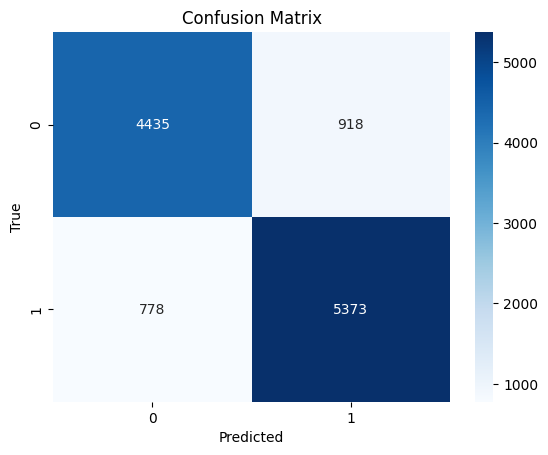

In [7]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Shown in the confusion matrix are the quantifiable data of the initial model's performance. The false positives and negatives are summed up to 1696, which are the total errors produced by the model.

## Hyperparameter Tuning

Next is to explore the ideal hyperparameter that yields the highest accuracy
or least loss. A small _k_ such as 5 can lead to overfitting, while a high _k_
may lead to underfitting. Thus, there must be a right hyperparameter for this model.

### Identifying the best _k_

We set a reasonable range for the hyperparameter tuning, which is from 1-31. The
typical range is up to 21, but to consider the dataset and to visualize the curve
better, we add an extra 10. We also only use odd hyperparameters to avoid ties. We also implement `weights='distance'` to ensure that closer neighbors have a higher influence on the classification, mitigating the noise often found in competitive gaming data.

In [8]:
# Set a hyperparameter range from 1-31
k_values = range(1, 51, 2)
cv_scores = []

# Iterate through the range to test for accuracy
for k in k_values:
    # Update pipeline k
    pipeline.set_params(knn__n_neighbors=k, knn__weights='distance')
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

With the hyperparameter tuned, we can visualize the the accuracy of the all the hyperparameters.

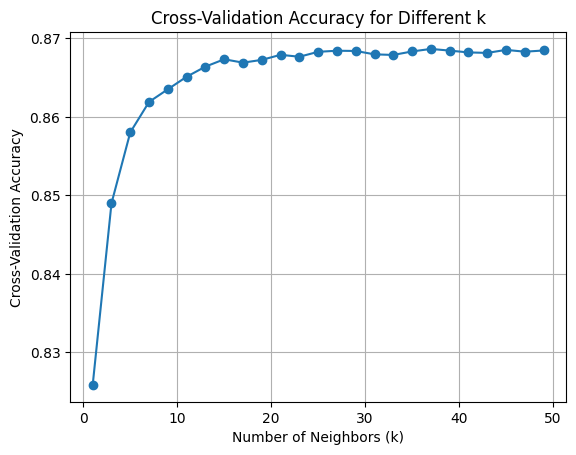

In [9]:
# Cross validation accuracy
plt.plot(k_values, cv_scores, marker="o")
plt.title("Cross-Validation Accuracy for Different k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.grid(True)
plt.show()

There is a sharp increase in accuracy in ranges of 1 to 10 for k, and a slower increase from 10 to 20. When **_k_ is 20 and above, the accuracy flattens**. The best _k_ can be found from _k_ = 20 and up. We will let the pipeline select the ideal _k_ based on the highest cross-validation accuracy.

In [ ]:
### Best _k_ results

In [10]:
# Best k selection
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k} with Cross-Validation Accuracy: {max(cv_scores):.6f}")

Best k: 37 with Cross-Validation Accuracy: 0.868657


The cross-validation process identified _k_ = 37 as the optimal neighborhood size with an accuracy of 0.868657. Interestingly, this is nearly identical to our baseline performance at _k_ = 5 (0.852573). We should further explore the confidence of the model in terms of its predictions through a probability distribution.

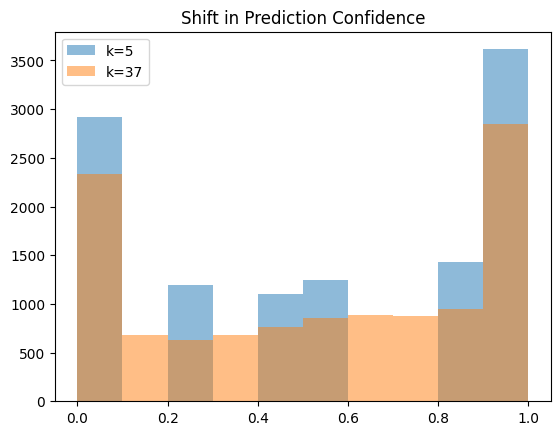

In [11]:
# Compare probability distributions
probs_k37 = pipeline.predict_proba(X_test)[:, 1]

plt.hist(probs_k5, alpha=0.5, label='k=5')
plt.hist(probs_k37, alpha=0.5, label='k=37')
plt.legend()
plt.title("Shift in Prediction Confidence")
plt.show()

As we can see, the **orange distribution (_k_ = 37) showed a more stable distribution of probability than the blue one (_k_ = 5)**. Despite _k_ = 5 producing higher probabilities of 0 or 1, it fails to have stability in its decision making, hence gaps from 0 to 0.2, 0.3 to 0.4, and 0.6 to 0.8. This is why _k_ = 37 is much more ideal for a more confident prediction. 

We also previously set `knn__weights='distance` which allows the model to prioritize the closest neighbors to influence the probability. Increasing the _k_ consults more neighbors and clarifies the decision better, providing lesser noise and sensitivity to outliers.

In [ ]:
#### Decision Boundary

We can also plot a decision boundary for _k_ = 5 and _k_ = 37 to clearly see the confidence of the decision.  

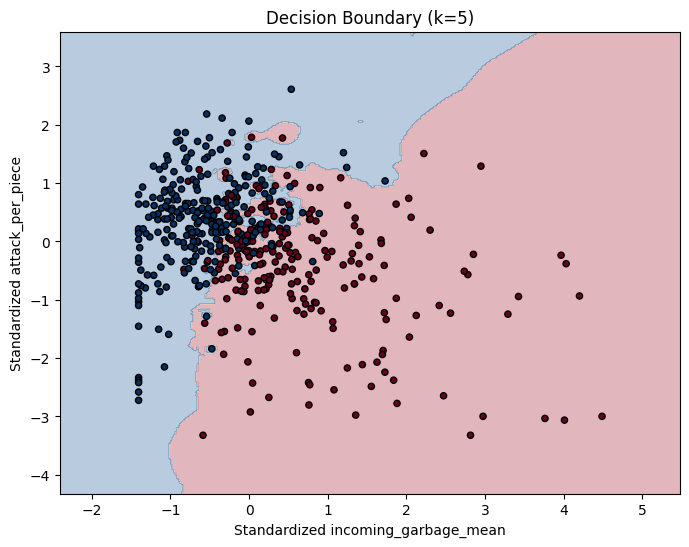

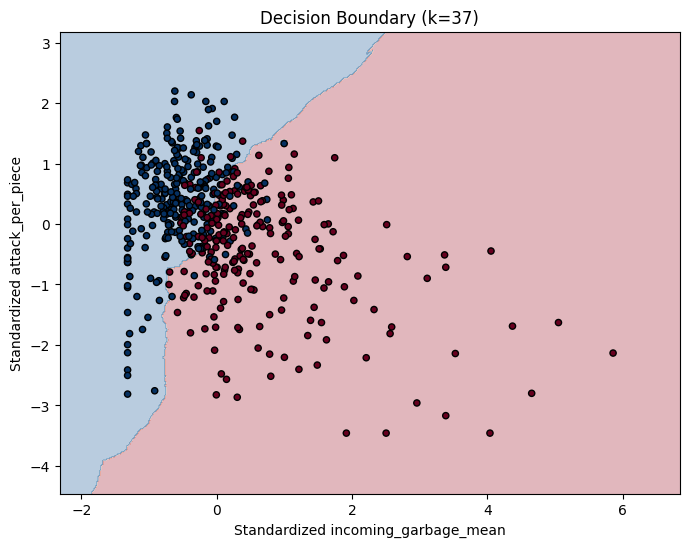

In [18]:
plot_knn_boundary(5, 'distance', "Decision Boundary (k=5)", X_train, y_train)
plot_knn_boundary(37, 'distance', "Decision Boundary (k=37)", X_train, y_train)

The decision boundary further supports our claim that **_k_ = 37 is more stable and confident than _k_ = 5**. They both have nearly identical accuracy results, but the decision boundary (or line) in _k_ = 37 is smoother than the latter. 

### Retraining the model

Now that the best _k_ is identified, we can retrain the model using that _k_ to
clearly visualize its performance.

In [12]:
# Model retraining using best k
pipeline.set_params(knn__n_neighbors=best_k, knn__weights='distance')
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",37
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",3

### Calculate Permutation Importance

Since kNN is a lazy learner and does not have feature importance scores, we use
permutation feature importance (pfi) to identify the top contributors to the model's
decision-making.

In [13]:
# We use the test set to see how important features are for generalization
result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Organize the data for visualization
feature_names = X.columns
importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

## Final Model Results

Final Model Accuracy (k=37): 0.869611

Final Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      5353
           1       0.86      0.90      0.88      6151

    accuracy                           0.87     11504
   macro avg       0.87      0.87      0.87     11504
weighted avg       0.87      0.87      0.87     11504



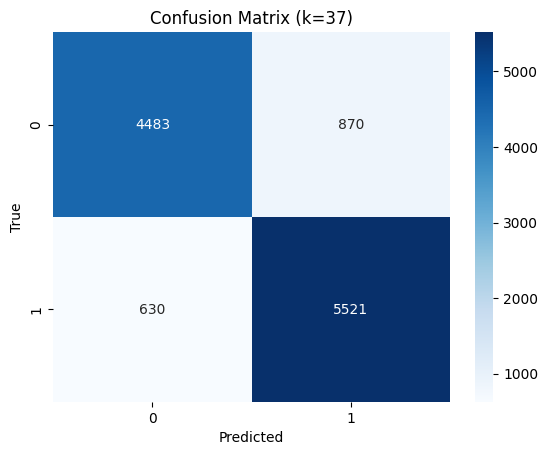

In [14]:
# Final model evaluation
final_y_pred = pipeline.predict(X_test)
final_accuracy = accuracy_score(y_test, final_y_pred)

print(f"Final Model Accuracy (k={best_k}): {final_accuracy:.6f}")
print("\nFinal Classification Report:\n")
print(classification_report(y_test, final_y_pred))

# Confusion matrix for final model
final_conf_matrix = confusion_matrix(y_test, final_y_pred)
sns.heatmap(final_conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.title(f"Confusion Matrix (k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The final model shows a **high predictive accuracy/f1-score (87%)**. It also has a high recall (0.90) for winning replays, showing a strong distinction for winning playstyles. 

### Feature Weights

We also want to discover what features influence the model more. We will plot the results of permutation feature importance in a bar plot.

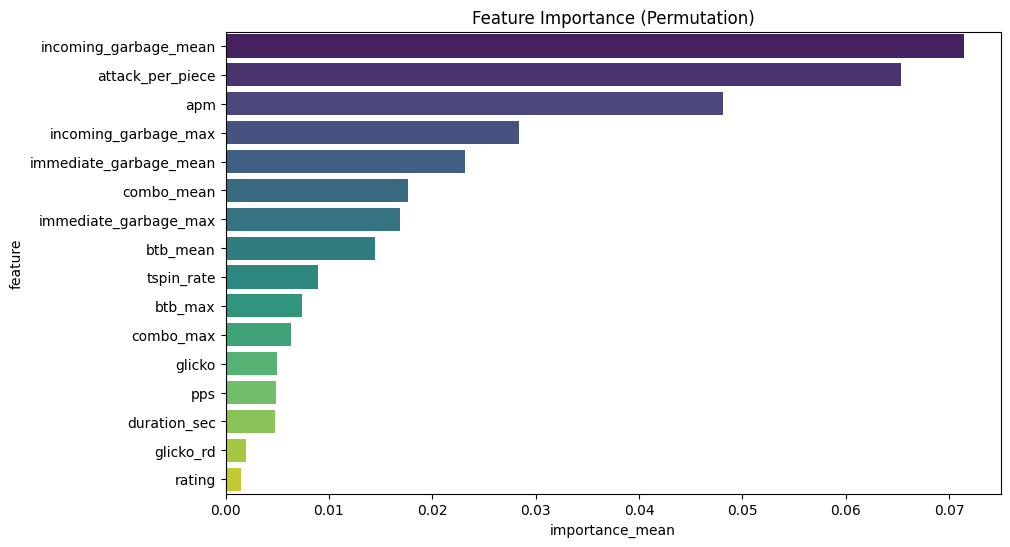

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="importance_mean",
    y="feature",
    data=importances_df,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Permutation)")
plt.show()

From the results, we can infer:
* `incoming_garbage_mean`: **This is the most important feature** that the model utilizes as it has a strong factor to winning/losing. From a Tetrio perspective, we can infer that **incoming garbage is a negative contributor**. As such, we can infer that players who fail to defend themselves against incoming garbage are more likely to lose than consistently attacking.
* `attack_per_piece` & `apm`: **Attack per piece and attacks per minute strongly contribute to winning**. Tetrio dictates attacks as the amount of garbage the player sends to their opponent. In relation to `pps` or pieces per second, having a strong attack with less pieces significantly impacts a match's outcome than speedily placing pieces.
* `btb_mean`, `combo_mean`, and `tspin_rate`: kNN fails to capture if these values are positive or negative contributors. However, this can give us an insight as to what moderately affects a match**.